## 1) What data do we have?

This project data focuses on **WBTC/WETH arbitrage research on Uniswap V2 vs SushiSwap V2**. The curated dataset contains three main tables:

- `pool_state_1m`: minute-by-minute pool state for each DEX (price, reserves, volume, stale flag)
- `swaps_raw`: raw swap-level events (time, direction, size, post-trade reserves)
- `arb_labels_1m`: minute-by-minute arbitrage labels for the best direction (`gross_edge_bps`, `fee_cost_bps`, `gas_cost_weth`, `net_edge_bps`, `opportunity_flag`)

Next, we load the data and inspect its structure.

In [18]:
from pathlib import Path
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid")

# Make the notebook work when it is executed from notebooks/
repo_root = Path.cwd()
if repo_root.name == "notebooks":
    repo_root = repo_root.parent

curated_dir = repo_root / "data" / "curated"
report_dir = repo_root / "outputs" / "report"

arb = pd.read_csv(curated_dir / "arb_labels_1m.csv", parse_dates=["timestamp"])
pool = pd.read_csv(curated_dir / "pool_state_1m.csv", parse_dates=["timestamp"])
swaps = pd.read_csv(curated_dir / "swaps_raw.csv", parse_dates=["timestamp"])

print("arb_labels_1m:", arb.shape)
print("pool_state_1m:", pool.shape)
print("swaps_raw:", swaps.shape)

display(arb.head(3))

arb_labels_1m: (43184, 15)
pool_state_1m: (86377, 12)
swaps_raw: (5831, 14)


,timestamp,buy_dex,sell_dex,gross_edge_weth,gross_edge_bps,fee_cost_weth,fee_cost_bps,gas_cost_weth,gas_cost_bps,net_edge_weth,net_edge_bps,base_fee_per_gas_wei,opportunity_flag,stale_state,split
0,2026-03-08 01:36:00+00:00,uniswap_v2,sushiswap_v2,-0.027363,-79.76501,0.020405,59.482564,0.000447,NaN,-0.048216,-140.552066,34082355.0,False,True,train
1,2026-03-08 01:37:00+00:00,uniswap_v2,sushiswap_v2,-0.027363,-79.76501,0.020405,59.482564,0.000447,NaN,-0.048216,-140.552066,34082355.0,False,True,train
2,2026-03-08 01:38:00+00:00,uniswap_v2,sushiswap_v2,-0.027363,-79.76501,0.020405,59.482564,0.000447,NaN,-0.048216,-140.552066,34082355.0,False,True,train


In [19]:
# Quick dictionary-style view: columns, nulls, and sample counts

def quick_profile(df, name):
    out = pd.DataFrame({
        "column": df.columns,
        "dtype": [str(df[c].dtype) for c in df.columns],
        "null_ratio": [df[c].isna().mean() for c in df.columns],
        "n_unique": [df[c].nunique(dropna=True) for c in df.columns],
    })
    print(f"\n{name} | rows={len(df):,}, cols={df.shape[1]}")
    return out

profile_arb = quick_profile(arb, "arb_labels_1m")
profile_pool = quick_profile(pool, "pool_state_1m")
profile_swaps = quick_profile(swaps, "swaps_raw")

print("\n=== key columns in arb_labels_1m ===")
display(profile_arb[profile_arb["column"].isin([
    "timestamp", "buy_dex", "sell_dex", "gross_edge_bps", "fee_cost_bps",
    "gas_cost_weth", "net_edge_bps", "opportunity_flag", "stale_state", "split"
])])

print("\n=== key columns in pool_state_1m ===")
display(profile_pool[profile_pool["column"].isin([
    "timestamp", "dex", "mid_price_eth_per_btc", "reserve_wbtc", "reserve_weth",
    "swap_count", "volume_wbtc", "volume_weth", "stale_state", "split"
])])


arb_labels_1m | rows=43,184, cols=15

pool_state_1m | rows=86,377, cols=12

swaps_raw | rows=5,831, cols=14

=== key columns in arb_labels_1m ===


,column,dtype,null_ratio,n_unique
0,timestamp,"datetime64[us, UTC]",0.0,43184
1,buy_dex,str,0.0,2
2,sell_dex,str,0.0,2
4,gross_edge_bps,float64,0.0,3323
6,fee_cost_bps,float64,0.0,3323
7,gas_cost_weth,float64,0.0,3323
10,net_edge_bps,float64,0.0,3323
12,opportunity_flag,bool,0.0,2
13,stale_state,bool,0.0,2
14,split,str,0.0,3



=== key columns in pool_state_1m ===


,column,dtype,null_ratio,n_unique
0,timestamp,"datetime64[us, UTC]",0.000000,43193
1,reserve_wbtc,float64,0.000000,4303
2,reserve_weth,float64,0.000000,4353
4,dex,str,0.000000,2
6,swap_count,int64,0.000000,22
7,volume_wbtc,float64,0.000000,3742
8,volume_weth,float64,0.000000,4035
9,mid_price_eth_per_btc,float64,0.000000,4354
10,stale_state,bool,0.000000,2
11,split,str,0.000104,3


## 2) Understand the data with charts

Focus on four things:

1. The distribution of `net_edge_bps` (how often it is above 0)
2. The share of `stale_state` rows (how much data is actually tradable)
3. The minute-level price spread between the two DEXs (when large dislocations appear)
4. Hour-of-day activity (when opportunities are more likely)


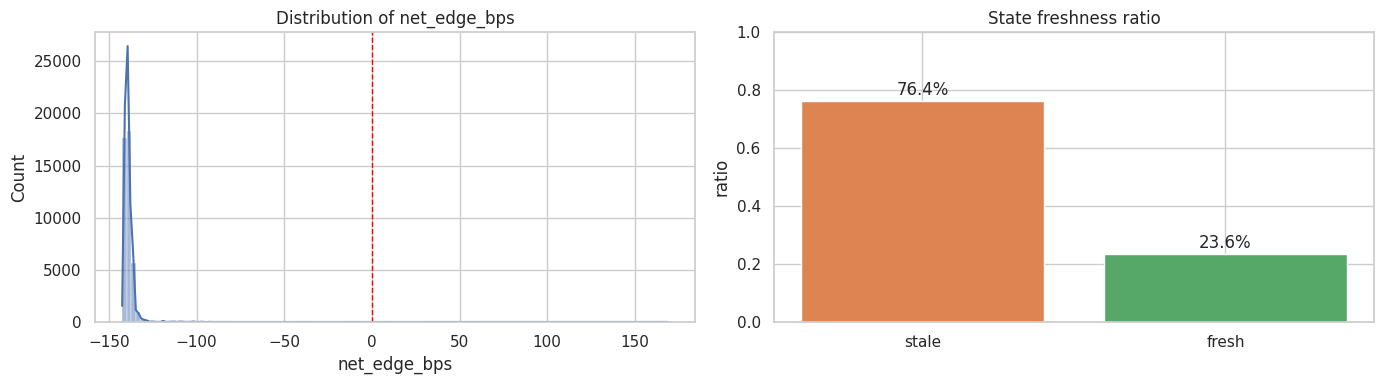

opportunity_flag count: 1
mean net_edge_bps: -138.9566


In [20]:
# Chart 1: net edge distribution + stale ratio

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sns.histplot(arb["net_edge_bps"], bins=120, kde=True, ax=axes[0], color="#4C72B0")
axes[0].axvline(0, color="red", linestyle="--", linewidth=1)
axes[0].set_title("Distribution of net_edge_bps")
axes[0].set_xlabel("net_edge_bps")

stale_stats = arb["stale_state"].value_counts(normalize=True).rename(index={True: "stale", False: "fresh"})
axes[1].bar(stale_stats.index, stale_stats.values, color=["#DD8452", "#55A868"])
axes[1].set_title("State freshness ratio")
axes[1].set_ylim(0, 1)
axes[1].set_ylabel("ratio")
for i, v in enumerate(stale_stats.values):
    axes[1].text(i, v + 0.02, f"{v:.1%}", ha="center")

plt.tight_layout()
plt.show()

print("opportunity_flag count:", int(arb["opportunity_flag"].sum()))
print("mean net_edge_bps:", round(float(arb["net_edge_bps"].mean()), 4))

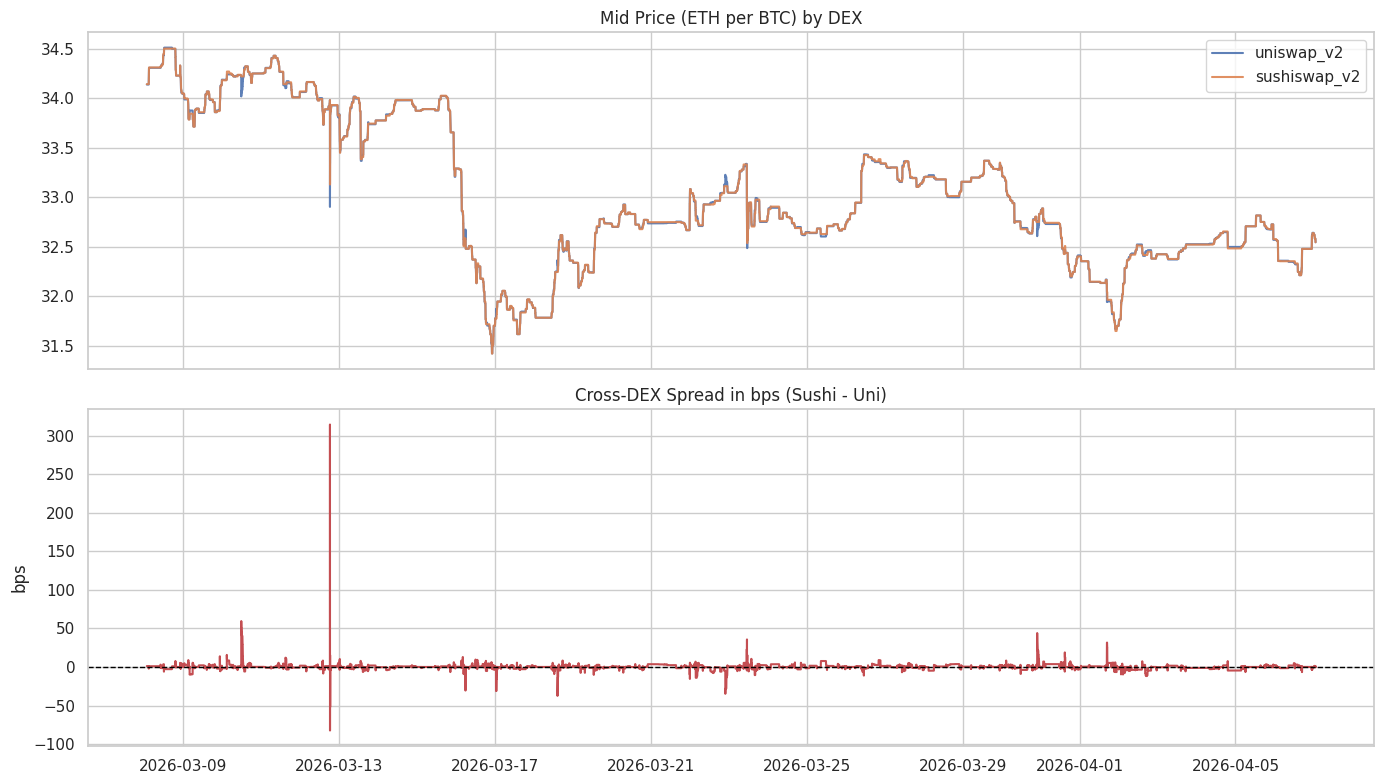

count    43184.000000
mean         0.151674
std          3.616057
min        -82.431486
1%          -8.979353
5%          -4.144063
95%          3.650965
99%          7.681784
max        314.458606
Name: spread_bps_sushi_minus_uni, dtype: float64


In [21]:
# Chart 2: minute-level price spread between the two DEXs (ETH per BTC)

price_pivot = (
    pool.pivot_table(index="timestamp", columns="dex", values="mid_price_eth_per_btc", aggfunc="last")
    .dropna()
    .sort_index()
)
price_pivot["spread_bps_sushi_minus_uni"] = (
    (price_pivot.get("sushiswap_v2") - price_pivot.get("uniswap_v2"))
    / price_pivot.get("uniswap_v2")
) * 10_000

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

axes[0].plot(price_pivot.index, price_pivot["uniswap_v2"], label="uniswap_v2", alpha=0.9)
axes[0].plot(price_pivot.index, price_pivot["sushiswap_v2"], label="sushiswap_v2", alpha=0.9)
axes[0].set_title("Mid Price (ETH per BTC) by DEX")
axes[0].legend(loc="upper right")

axes[1].plot(price_pivot.index, price_pivot["spread_bps_sushi_minus_uni"], color="#C44E52")
axes[1].axhline(0, color="black", linestyle="--", linewidth=1)
axes[1].set_title("Cross-DEX Spread in bps (Sushi - Uni)")
axes[1].set_ylabel("bps")

plt.tight_layout()
plt.show()

print(price_pivot["spread_bps_sushi_minus_uni"].describe(percentiles=[0.01, 0.05, 0.95, 0.99]))

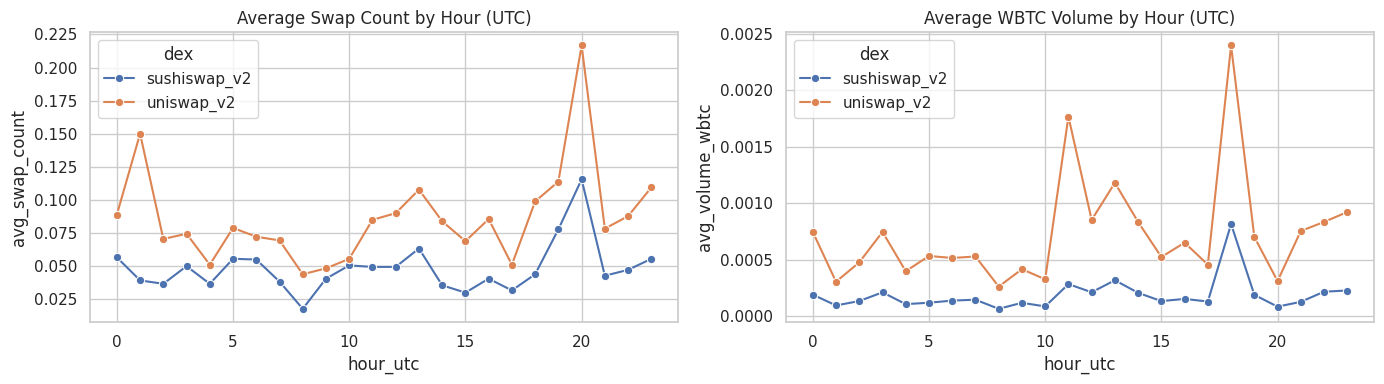

,dex,hour_utc,avg_swap_count,avg_volume_wbtc
44,uniswap_v2,20,0.216667,0.000311
25,uniswap_v2,1,0.150028,0.000305
20,sushiswap_v2,20,0.115556,0.000084
43,uniswap_v2,19,0.113889,0.000702
47,uniswap_v2,23,0.109444,0.000923
37,uniswap_v2,13,0.107778,0.001181
42,uniswap_v2,18,0.098889,0.002399
36,uniswap_v2,12,0.090000,0.000852
24,uniswap_v2,0,0.088889,0.000746
46,uniswap_v2,22,0.087778,0.000835


In [22]:
# Chart 3: hourly activity (swap count and volume)

pool_hour = pool.copy()
pool_hour["hour_utc"] = pool_hour["timestamp"].dt.hour
hourly = (
    pool_hour.groupby(["dex", "hour_utc"], as_index=False)
    .agg(avg_swap_count=("swap_count", "mean"), avg_volume_wbtc=("volume_wbtc", "mean"))
)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.lineplot(data=hourly, x="hour_utc", y="avg_swap_count", hue="dex", marker="o", ax=axes[0])
axes[0].set_title("Average Swap Count by Hour (UTC)")
axes[0].set_xlabel("hour_utc")

sns.lineplot(data=hourly, x="hour_utc", y="avg_volume_wbtc", hue="dex", marker="o", ax=axes[1])
axes[1].set_title("Average WBTC Volume by Hour (UTC)")
axes[1].set_xlabel("hour_utc")
axes[1].set_ylabel("avg_volume_wbtc")

plt.tight_layout()
plt.show()

hourly.sort_values(["avg_swap_count", "avg_volume_wbtc"], ascending=False).head(10)

In [6]:
arb.head()

,timestamp,buy_dex,sell_dex,gross_edge_weth,gross_edge_bps,fee_cost_weth,fee_cost_bps,gas_cost_weth,gas_cost_bps,net_edge_weth,net_edge_bps,base_fee_per_gas_wei,opportunity_flag,stale_state,split
0,2026-03-08 01:36:00+00:00,uniswap_v2,sushiswap_v2,-0.027363,-79.76501,0.020405,59.482564,0.000447,NaN,-0.048216,-140.552066,34082355.0,False,True,train
1,2026-03-08 01:37:00+00:00,uniswap_v2,sushiswap_v2,-0.027363,-79.76501,0.020405,59.482564,0.000447,NaN,-0.048216,-140.552066,34082355.0,False,True,train
2,2026-03-08 01:38:00+00:00,uniswap_v2,sushiswap_v2,-0.027363,-79.76501,0.020405,59.482564,0.000447,NaN,-0.048216,-140.552066,34082355.0,False,True,train
3,2026-03-08 01:39:00+00:00,uniswap_v2,sushiswap_v2,-0.027363,-79.76501,0.020405,59.482564,0.000447,NaN,-0.048216,-140.552066,34082355.0,False,True,train
4,2026-03-08 01:40:00+00:00,uniswap_v2,sushiswap_v2,-0.027363,-79.76501,0.020405,59.482564,0.000447,NaN,-0.048216,-140.552066,34082355.0,False,True,train


In [9]:
arb[arb["buy_dex"] == "sushiswap_v2"]

,timestamp,buy_dex,sell_dex,gross_edge_weth,gross_edge_bps,fee_cost_weth,fee_cost_bps,gas_cost_weth,gas_cost_bps,net_edge_weth,net_edge_bps,base_fee_per_gas_wei,opportunity_flag,stale_state,split
73,2026-03-08 02:49:00+00:00,sushiswap_v2,uniswap_v2,-0.027363,-79.269828,0.020580,59.619966,0.000448,NaN,-0.048392,-140.187212,35729322.0,False,False,train
511,2026-03-08 10:07:00+00:00,sushiswap_v2,uniswap_v2,-0.027830,-80.326284,0.020655,59.616710,0.000446,NaN,-0.048931,-141.231285,28826486.0,False,False,train
512,2026-03-08 10:08:00+00:00,sushiswap_v2,uniswap_v2,-0.027830,-80.326284,0.020655,59.616710,0.000446,NaN,-0.048931,-141.231285,28826486.0,False,False,train
521,2026-03-08 10:17:00+00:00,sushiswap_v2,uniswap_v2,-0.027757,-80.092880,0.020661,59.617400,0.000446,NaN,-0.048865,-140.998304,29025292.0,False,False,train
522,2026-03-08 10:18:00+00:00,sushiswap_v2,uniswap_v2,-0.027757,-80.092880,0.020661,59.617400,0.000446,NaN,-0.048865,-140.998304,29025292.0,False,False,train
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
43107,2026-04-07 00:03:00+00:00,sushiswap_v2,uniswap_v2,-0.025873,-78.539846,0.019641,59.623358,0.000449,NaN,-0.045963,-139.527352,42617773.0,False,True,test
43108,2026-04-07 00:04:00+00:00,sushiswap_v2,uniswap_v2,-0.025873,-78.539846,0.019641,59.623358,0.000449,NaN,-0.045963,-139.527352,42617773.0,False,True,test
43109,2026-04-07 00:05:00+00:00,sushiswap_v2,uniswap_v2,-0.025873,-78.539846,0.019641,59.623358,0.000449,NaN,-0.045963,-139.527352,42617773.0,False,True,test
43110,2026-04-07 00:06:00+00:00,sushiswap_v2,uniswap_v2,-0.025873,-78.539846,0.019641,59.623358,0.000449,NaN,-0.045963,-139.527352,42617773.0,False,True,test


In [10]:
swaps.head()

,timestamp,block_number,dex,pair_address,transaction_hash,log_index,amount_wbtc,amount_weth,volume_wbtc,volume_weth,reserve_wbtc_post,reserve_weth_post,mid_price_eth_per_btc,trade_direction
0,2026-03-08 02:39:11+00:00,24609810,uniswap_v2,0xbb2b8038a1640196fbe3e38816f3e67cba72d940,0x11baf85c840eef996c6bb4395de25271e39f4d37179a...,230,-0.000029,0.001000,0.000029,0.001000,56.597724,1932.307091,34.141074,buy_wbtc
1,2026-03-08 02:39:23+00:00,24609811,uniswap_v2,0xbb2b8038a1640196fbe3e38816f3e67cba72d940,0x25e1029db544905d705334da2d9f6c24ee2963fdbaf8...,201,-0.000067,0.002297,0.000067,0.002297,56.597657,1932.309387,34.141155,buy_wbtc
2,2026-03-08 02:47:47+00:00,24609853,uniswap_v2,0xbb2b8038a1640196fbe3e38816f3e67cba72d940,0x9aa001c3230bf161a469f8859a22845ce130829e9b9a...,309,-0.004776,0.163572,0.004776,0.163572,56.592948,1932.475256,34.146927,buy_wbtc
3,2026-03-08 02:48:11+00:00,24609855,uniswap_v2,0xbb2b8038a1640196fbe3e38816f3e67cba72d940,0xd8e0b3ceeaef3952dc4af72510fb1f17c936d402257a...,142,-0.018841,0.645512,0.018841,0.645512,56.574107,1933.120768,34.169709,buy_wbtc
4,2026-03-08 02:48:11+00:00,24609855,sushiswap_v2,0xceff51756c56ceffca006cd410b03ffc46dd3a58,0xd8e0b3ceeaef3952dc4af72510fb1f17c936d402257a...,211,-0.005642,0.193306,0.005642,0.193306,15.617774,533.654844,34.169712,buy_wbtc


## 3) View buy/sell price trends by exchange (executable prices)

Here, "buy price" and "sell price" are not order-book quotes. They are the **unit prices implied by an actual AMM trade of a fixed WBTC amount (default: 0.10)**:

- Buy price (ask-like) = WETH paid to buy `q` WBTC / `q`
- Sell price (bid-like) = WETH received when selling `q` WBTC / `q`

This is much closer to real arbitrage execution.


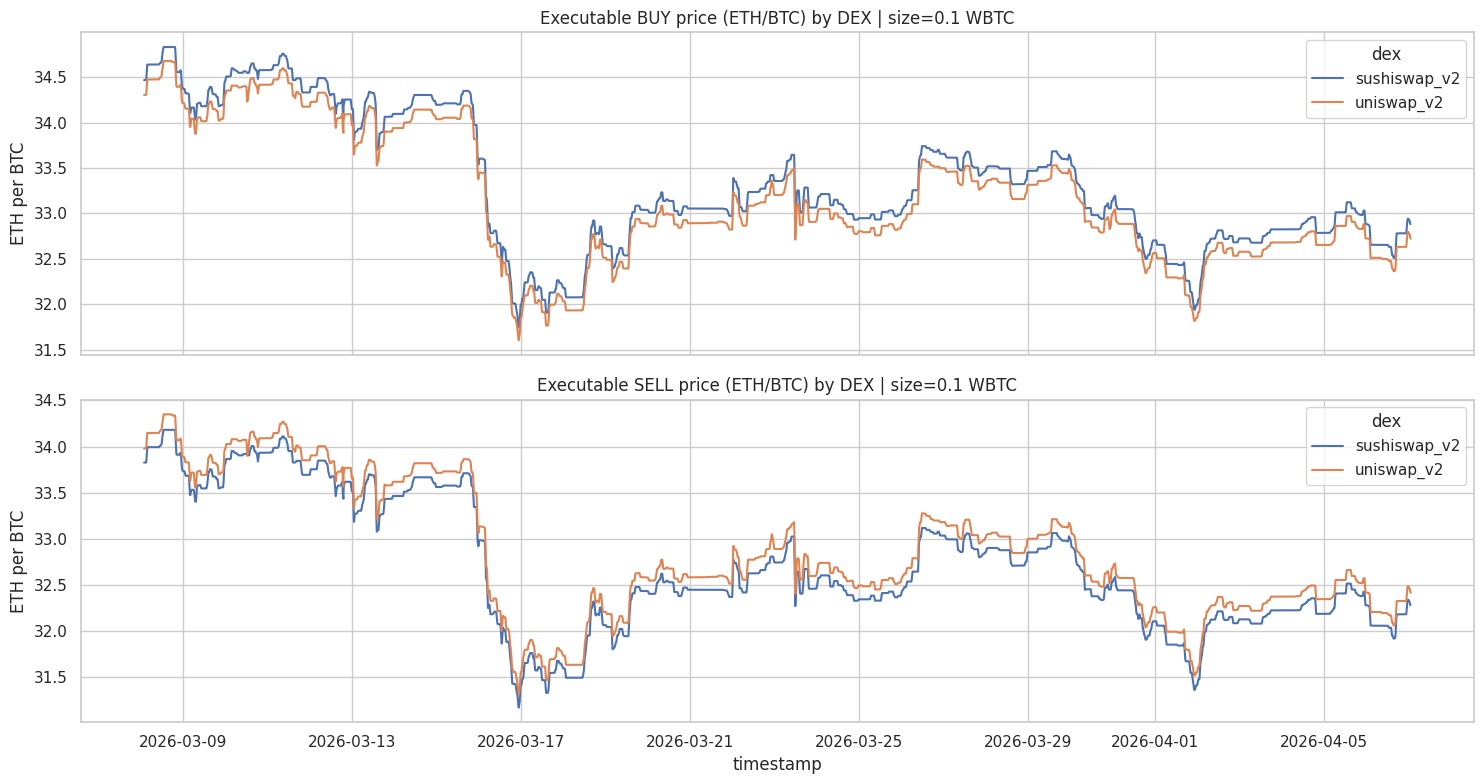

,count,mean,std,min,5%,50%,95%,max
dex,,,,,,,,
sushiswap_v2,43184.0,187.454588,1.402235,184.339957,185.259319,187.005553,189.887766,190.373750
uniswap_v2,43193.0,95.238890,0.374603,94.391545,94.641624,95.127557,95.885567,96.024567


In [23]:
# Chart 4: executable buy/sell price trends by exchange

trade_size_wbtc = 0.10
fee_rate = 0.003  # typical V2 30 bps fee

ps = pool.copy()
ps = ps[(ps["reserve_wbtc"] > trade_size_wbtc) & (ps["reserve_weth"] > 0)].copy()

# Buying q WBTC costs how much WETH (exact out)
ps["buy_cost_weth"] = (
    (ps["reserve_weth"] * trade_size_wbtc / (ps["reserve_wbtc"] - trade_size_wbtc))
    / (1 - fee_rate)
)
# Selling q WBTC receives how much WETH (exact in)
ps["sell_return_weth"] = (
    ps["reserve_weth"] * (trade_size_wbtc * (1 - fee_rate))
    / (ps["reserve_wbtc"] + trade_size_wbtc * (1 - fee_rate))
)

ps["buy_price_eth_per_btc"] = ps["buy_cost_weth"] / trade_size_wbtc
ps["sell_price_eth_per_btc"] = ps["sell_return_weth"] / trade_size_wbtc

# Optional smoothing to make the trend easier to read
ps = ps.sort_values(["dex", "timestamp"]).copy()
ps["buy_price_smooth"] = ps.groupby("dex")["buy_price_eth_per_btc"].transform(lambda s: s.rolling(30, min_periods=1).mean())
ps["sell_price_smooth"] = ps.groupby("dex")["sell_price_eth_per_btc"].transform(lambda s: s.rolling(30, min_periods=1).mean())

fig, axes = plt.subplots(2, 1, figsize=(15, 8), sharex=True)

sns.lineplot(data=ps, x="timestamp", y="buy_price_smooth", hue="dex", ax=axes[0])
axes[0].set_title(f"Executable BUY price (ETH/BTC) by DEX | size={trade_size_wbtc} WBTC")
axes[0].set_ylabel("ETH per BTC")

sns.lineplot(data=ps, x="timestamp", y="sell_price_smooth", hue="dex", ax=axes[1])
axes[1].set_title(f"Executable SELL price (ETH/BTC) by DEX | size={trade_size_wbtc} WBTC")
axes[1].set_ylabel("ETH per BTC")
axes[1].set_xlabel("timestamp")

plt.tight_layout()
plt.show()

# Extra: internal bid-ask spread for each exchange
spread_summary = (
    ps.assign(internal_spread_bps=(ps["buy_price_eth_per_btc"] / ps["sell_price_eth_per_btc"] - 1) * 10_000)
      .groupby("dex")["internal_spread_bps"]
      .describe(percentiles=[0.05, 0.5, 0.95])
)
spread_summary

## 4) A minimal time-series mock: use the next 5-minute sell price as a fake forecast

Instead of doing same-minute cross-DEX arbitrage, this section turns the problem into a simple forecasting exercise:

- Look at the current buy price `buy_price`
- Use a mock predictor to estimate the sell price `5 minutes ahead`
- If `predicted_sell_price - buy_price` is large enough, buy now and sell 5 minutes later

Note: the predictor is cheating on purpose. It uses the true future sell price as the forecast target so we can test the idea first.


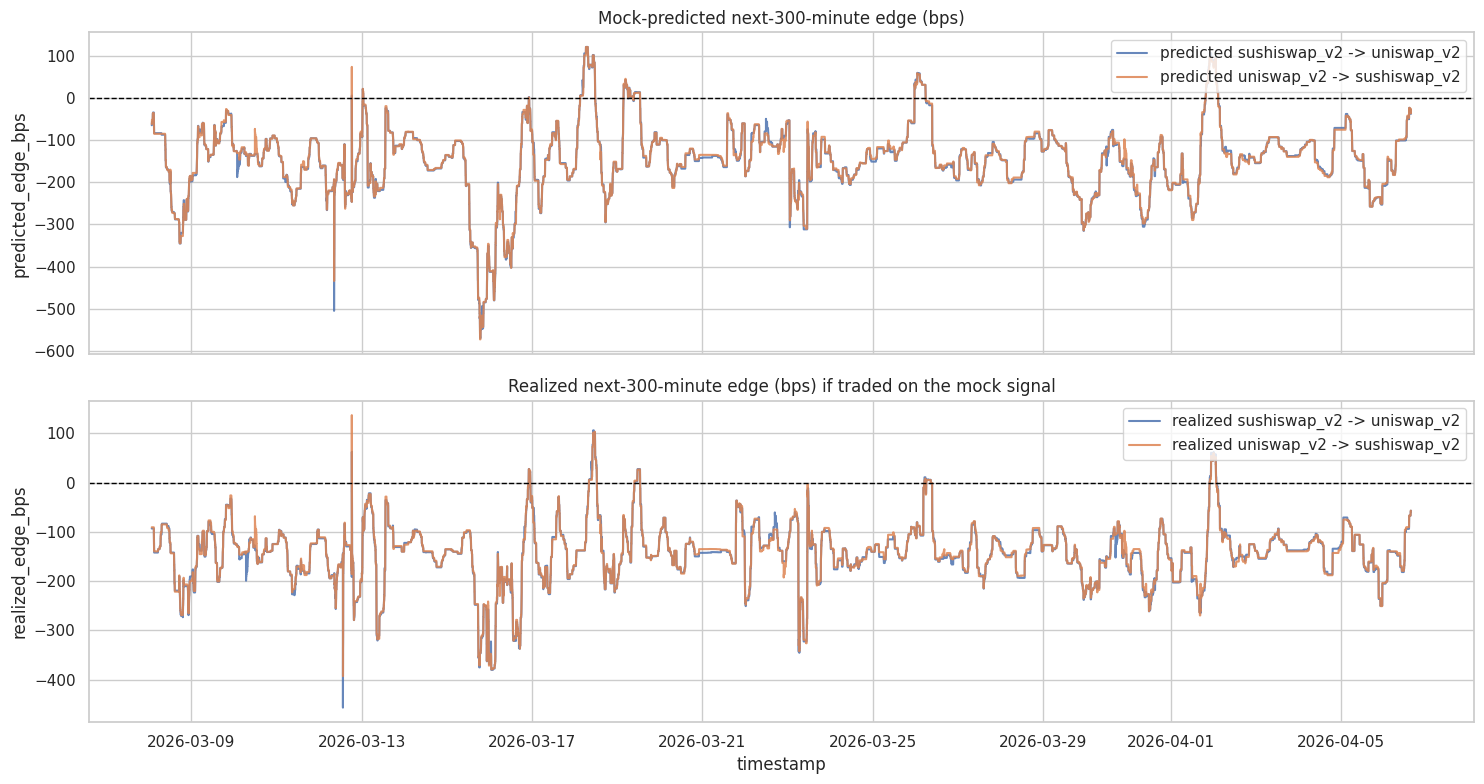

,signals,avg_predicted_edge_bps,avg_realized_edge_bps,hit_rate
direction,,,,
uniswap_v2 -> sushiswap_v2,1905,-146.107658,-142.606417,0.022262
sushiswap_v2 -> uniswap_v2,1889,-146.888904,-143.389585,0.021553


In [ ]:
# Chart 5: mock_predict + five-minute-ahead backtest

horizon_minutes = 5
signal_threshold_bps = 0.0

# 1) Reshape each exchange's executable buy/sell prices into a long table
price_long = ps[["timestamp", "dex", "buy_price_eth_per_btc", "sell_price_eth_per_btc"]].copy()
price_long = price_long.sort_values(["dex", "timestamp"])

# 2) mock_predict: use the true future sell price 5 minutes ahead as the predicted sell price
price_long["predicted_future_sell_price_eth_per_btc"] = (
    price_long.groupby("dex")["sell_price_eth_per_btc"].shift(-horizon_minutes)
)

# 3) Two directions: buy at the current time on one DEX and sell 5 minutes later on the other DEX
pairs = [("uniswap_v2", "sushiswap_v2"), ("sushiswap_v2", "uniswap_v2")]
records = []

for buy_dex, sell_dex in pairs:
    buy_df = price_long[price_long["dex"] == buy_dex][["timestamp", "buy_price_eth_per_btc"]].rename(
        columns={"buy_price_eth_per_btc": "current_buy_price"}
    )
    sell_pred_df = price_long[price_long["dex"] == sell_dex][[
        "timestamp",
        "predicted_future_sell_price_eth_per_btc",
        "sell_price_eth_per_btc",
    ]].rename(
        columns={
            "predicted_future_sell_price_eth_per_btc": "predicted_sell_price_future",
            "sell_price_eth_per_btc": "realized_sell_price_future",
        }
    )

    # Align the future sell price back to the current timestamp t
    sell_pred_df["timestamp"] = sell_pred_df["timestamp"] - pd.Timedelta(minutes=horizon_minutes)

    tmp = buy_df.merge(sell_pred_df, on="timestamp", how="inner").dropna()
    tmp["direction"] = f"{buy_dex} -> {sell_dex}"
    tmp["predicted_edge_bps"] = (
        (tmp["predicted_sell_price_future"] - tmp["current_buy_price"]) / tmp["current_buy_price"] * 10_000
    )
    tmp["realized_edge_bps"] = (
        (tmp["realized_sell_price_future"] - tmp["current_buy_price"]) / tmp["current_buy_price"] * 10_000
    )
    tmp["signal"] = tmp["predicted_edge_bps"] > signal_threshold_bps
    records.append(tmp)

mock_bt_5m = pd.concat(records, ignore_index=True)

# 4) Summary statistics
backtest_summary_5m = (
    mock_bt_5m.groupby("direction")
    .agg(
        signals=("signal", "sum"),
        avg_predicted_edge_bps=("predicted_edge_bps", "mean"),
        avg_realized_edge_bps=("realized_edge_bps", "mean"),
        hit_rate=("realized_edge_bps", lambda s: (s > 0).mean()),
    )
    .sort_values("avg_realized_edge_bps", ascending=False)
)

# 5) Plot predicted edge vs realized edge
fig, axes = plt.subplots(2, 1, figsize=(15, 8), sharex=True)

for direction, grp in mock_bt_5m.groupby("direction"):
    axes[0].plot(grp["timestamp"], grp["predicted_edge_bps"], label=f"predicted {direction}", alpha=0.85)
    axes[1].plot(grp["timestamp"], grp["realized_edge_bps"], label=f"realized {direction}", alpha=0.85)

axes[0].axhline(signal_threshold_bps, color="black", linestyle="--", linewidth=1)
axes[0].set_title(f"Mock-predicted next-{horizon_minutes}-minute edge (bps)")
axes[0].set_ylabel("predicted_edge_bps")
axes[0].legend(loc="upper right")

axes[1].axhline(0, color="black", linestyle="--", linewidth=1)
axes[1].set_title(f"Realized next-{horizon_minutes}-minute edge (bps) if traded on the mock signal")
axes[1].set_ylabel("realized_edge_bps")
axes[1].set_xlabel("timestamp")
axes[1].legend(loc="upper right")

plt.tight_layout()
plt.show()

backtest_summary_5m